<a href="https://colab.research.google.com/github/cassiecinzori/ECON3916/blob/main/Labs/Lecture10/Causality_%26_Spurious_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Causality & Spurious Regression
### Cassandra Cinzori

In [2]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

## 2. Lab Instructions: Structural Forensics
#### Step 1: Live Data Ingestion (FRED)

In [3]:
start = "2010-01-01"
end   = "2024-01-01"

series = {
    "CPIAUCSL": "cpi",      # Consumer Price Index
    "UNRATE":   "unrate",   # Unemployment Rate
    "FEDFUNDS": "fedfunds", # Federal Funds Rate
    "INDPRO":   "indpro",   # Industrial Production Index
    "M2SL":     "m2",       # M2 Money Supply
}

df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()
print("Shape:", df.shape)
display(df.head())

Shape: (169, 5)


,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0


## Step 2: The Raw Correlation Matrix

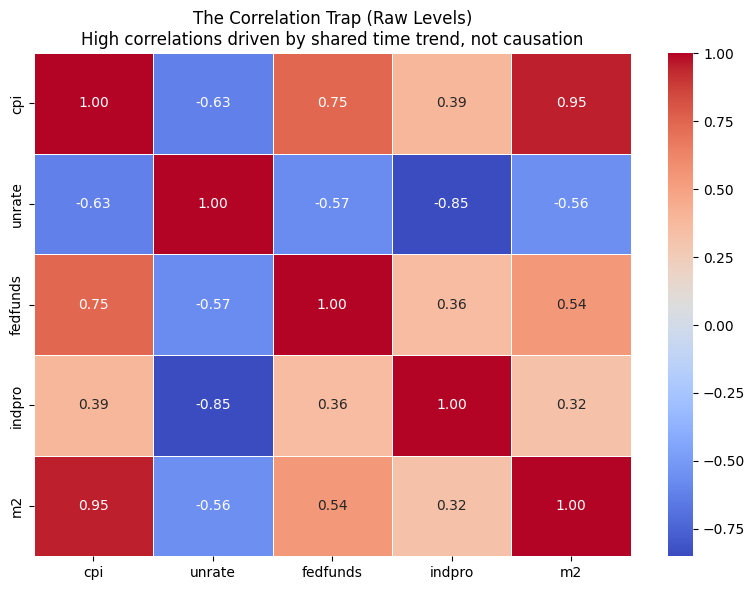

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("The Correlation Trap (Raw Levels)\nHigh correlations driven by shared time trend, not causation")
plt.tight_layout()
plt.show()

## Step 3: Diagnosing Multicollinearity (VIF)

In [5]:
# Define predictors (X). We leave out CPI as it is our theoretical target.
X = df[['unrate', 'fedfunds', 'indpro', 'm2']]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"]     = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nVariance Inflation Factors (Raw Levels):")
display(vif_data)


Variance Inflation Factors (Raw Levels):


,Feature,VIF
0,const,4252.825829
1,unrate,6.206882
2,fedfunds,1.727582
3,indpro,4.290455
4,m2,1.780273


## Step 4: The Transformation Fix (YoY Growth)

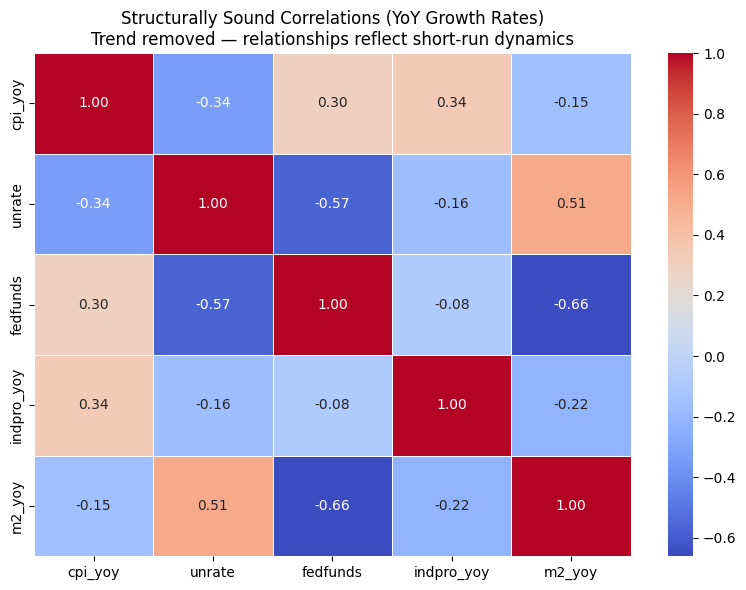

In [6]:
df_t = df.copy()

for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)

df_t = df_t.dropna()

cols_transformed = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']

plt.figure(figsize=(8, 6))
sns.heatmap(df_t[cols_transformed].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Structurally Sound Correlations (YoY Growth Rates)\nTrend removed — relationships reflect short-run dynamics")
plt.tight_layout()
plt.show()

## Step 5: Causal Graphing (DAG Construction)

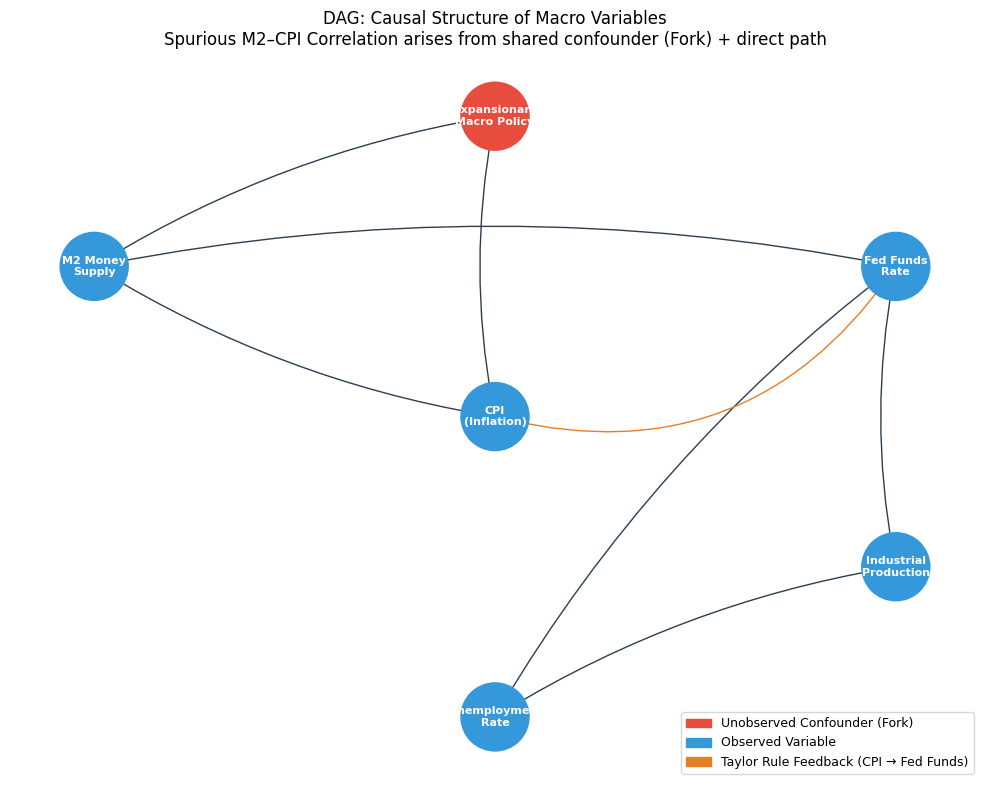

In [8]:
G = nx.DiGraph()

nodes = [
    "Expansionary\nMacro Policy",
    "M2 Money\nSupply",
    "CPI\n(Inflation)",
    "Fed Funds\nRate",
    "Industrial\nProduction",
    "Unemployment\nRate",
]
G.add_nodes_from(nodes)

edges = [
    ("Expansionary\nMacro Policy", "M2 Money\nSupply"),
    ("Expansionary\nMacro Policy", "CPI\n(Inflation)"),
    ("M2 Money\nSupply",           "CPI\n(Inflation)"),
    ("Fed Funds\nRate",            "M2 Money\nSupply"),
    ("Fed Funds\nRate",            "Industrial\nProduction"),
    ("Fed Funds\nRate",            "Unemployment\nRate"),
    ("Industrial\nProduction",     "Unemployment\nRate"),
    ("CPI\n(Inflation)",           "Fed Funds\nRate"),   # Taylor Rule feedback
]
G.add_edges_from(edges)

pos = {
    "Expansionary\nMacro Policy": (0,  2),
    "M2 Money\nSupply":           (-2, 1),
    "CPI\n(Inflation)":           (0,  0),
    "Fed Funds\nRate":            (2,  1),
    "Industrial\nProduction":     (2, -1),
    "Unemployment\nRate":         (0, -2),
}

fig, ax = plt.subplots(figsize=(10, 8))

node_colors = ["#e74c3c" if "Policy" in n else "#3498db" for n in G.nodes()]
feedback_edge  = [("CPI\n(Inflation)", "Fed Funds\nRate")]
structural_edges = [e for e in G.edges() if e not in feedback_edge]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2400, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color="white", font_weight="bold", ax=ax)
nx.draw_networkx_edges(
    G, pos, edgelist=structural_edges,
    edge_color="#2c3e50", arrows=True,
    arrowstyle="-|>", arrowsize=20,
    connectionstyle="arc3,rad=0.1", ax=ax
)
nx.draw_networkx_edges(
    G, pos, edgelist=feedback_edge,
    edge_color="#e67e22", arrows=True,
    arrowstyle="-|>", arrowsize=20,
    connectionstyle="arc3,rad=0.35", ax=ax
)

legend_handles = [
    mpatches.Patch(color="#e74c3c", label="Unobserved Confounder (Fork)"),
    mpatches.Patch(color="#3498db", label="Observed Variable"),
    mpatches.Patch(color="#e67e22", label="Taylor Rule Feedback (CPI → Fed Funds)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)
ax.set_title(
    "DAG: Causal Structure of Macro Variables\n"
    "Spurious M2–CPI Correlation arises from shared confounder (Fork) + direct path",
    fontsize=12
)
ax.axis("off")
plt.tight_layout()
plt.show()

## 3. AI-Assisted Expansion: Scaling to Interactive Dashboards

In [9]:
# =============================================================================
# Interactive Correlation Heatmap Dashboard
# Toggles between Raw Levels and YoY Growth Rate correlation matrices
# =============================================================================

import plotly.graph_objects as go
import numpy as np

# -----------------------------------------------------------------------------
# 1. Build the two correlation matrices from your existing DataFrames
# -----------------------------------------------------------------------------

# Raw levels — the 5 original untransformed series
raw_cols = ['cpi', 'unrate', 'fedfunds', 'indpro', 'm2']
corr_raw = df[raw_cols].corr()

# YoY transformed — trending variables replaced with % growth rates
yoy_cols = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
corr_yoy = df_t[yoy_cols].corr()

# Shared axis labels (rename yoy cols to clean display labels)
labels = ['CPI', 'Unemployment', 'Fed Funds', 'Ind. Production', 'M2']

# -----------------------------------------------------------------------------
# 2. Pre-compute annotation text for each matrix
#    Plotly heatmaps don't auto-annotate, so we build text arrays manually.
#    Each cell gets a string like "0.97" or "-0.23".
# -----------------------------------------------------------------------------

def make_annotations(corr_matrix):
    """Return a 2D list of rounded correlation strings for heatmap cells."""
    return [[f"{val:.2f}" for val in row] for row in corr_matrix.values]

text_raw = make_annotations(corr_raw)
text_yoy = make_annotations(corr_yoy)

# -----------------------------------------------------------------------------
# 3. Create the figure with TWO Heatmap traces
#    Only the first trace is visible at load time (visible=True).
#    The second is hidden (visible=False) until the dropdown selects it.
# -----------------------------------------------------------------------------

fig = go.Figure()

# --- Trace 0: Raw Levels ---
fig.add_trace(go.Heatmap(
    z=corr_raw.values,          # the correlation matrix as a 2D array
    x=labels,                   # x-axis tick labels
    y=labels,                   # y-axis tick labels
    text=text_raw,              # annotation strings per cell
    texttemplate="%{text}",     # tells Plotly to render the text array
    colorscale='RdBu',          # red = negative, white = zero, blue = positive
    zmin=-1, zmax=1,            # fix color scale bounds for comparability
    reversescale=True,          # flip so blue = positive (conventional)
    colorbar=dict(title="r"),   # label the colorbar
    visible=True,               # shown on initial load
    name="Raw Levels"
))

# --- Trace 1: YoY Growth ---
fig.add_trace(go.Heatmap(
    z=corr_yoy.values,
    x=labels,
    y=labels,
    text=text_yoy,
    texttemplate="%{text}",
    colorscale='RdBu',
    zmin=-1, zmax=1,
    reversescale=True,
    colorbar=dict(title="r"),
    visible=False,              # hidden until user selects from dropdown
    name="YoY Growth"
))

# -----------------------------------------------------------------------------
# 4. Define the dropdown using `updatemenus`
#
# HOW IT WORKS (architecture):
#   - `updatemenus` is a list of menu objects attached to the figure layout.
#   - Each button in the menu carries an `args` payload: a list of
#     [trace_property_dict, layout_property_dict].
#   - When clicked, Plotly calls figure.update() with those args — it patches
#     only the specified properties without re-rendering the whole figure.
#   - The visibility trick [True, False] / [False, True] activates exactly
#     one trace at a time by pushing a `visible` update to each trace index.
#   - No Python re-runs. This is pure client-side JavaScript under the hood;
#     both traces are already embedded in the HTML/JSON, the button just
#     toggles which one is rendered.
# -----------------------------------------------------------------------------

fig.update_layout(
    updatemenus=[
        dict(
            active=0,               # which button is selected on load (index 0)
            buttons=[
                dict(
                    label="Raw Levels",
                    method="update",    # "update" patches both traces AND layout
                    args=[
                        {"visible": [True, False]},           # trace visibility
                        {"title": "Correlation Matrix — Raw Levels<br>"
                                  "<sup>Spurious trend-driven correlations</sup>"}
                    ]
                ),
                dict(
                    label="YoY Growth Rates",
                    method="update",
                    args=[
                        {"visible": [False, True]},
                        {"title": "Correlation Matrix — YoY Growth Rates<br>"
                                  "<sup>Trend removed — structural relationships</sup>"}
                    ]
                ),
            ],
            direction="down",
            showactive=True,
            x=0.0, xanchor="left",
            y=1.18, yanchor="top",
        )
    ],
    # Initial title (matches active=0, i.e. Raw Levels)
    title=dict(
        text="Correlation Matrix — Raw Levels<br>"
             "<sup>Spurious trend-driven correlations</sup>",
        x=0.5,
        xanchor="center"
    ),
    width=620,
    height=580,
    font=dict(size=12),
    margin=dict(t=120, l=80, r=40, b=80),
)

fig.show()